# Final Deliverable

**Author:** Stella Dong

*Department of Computer Science & Engineering, Texas A&M University*  
*This work was completed as part of CSCE 676: Data Mining and Analysis, taught by Prof. James Caverlee.*

The Github repository of this project can be found here: [Github link](https://github.com/stellasdong/676_project/).

---

## Unsupervised Patient Clustering via Diagnosis Code Representations

**Research Question:** Do coarse body-system-level diagnosis features produce clusters as meaningful as fine-grained CCSR category features, and does a hybrid approach offer the best tradeoff between interpretability and granularity?

We evaluate three patient feature representations derived from ICD-10 diagnosis codes:
1. **Body System (coarse baseline)** — ~20 HCUP CCSR body system flags
2. **Full CCSR Categories (fine-grained)** — hundreds of clinical categories, TF-IDF weighted
3. **Hybrid** — body systems concatenated with top-K CCSR categories

Clustering algorithms: **KMeans** and **DBSCAN**. Evaluation: silhouette score, Davies–Bouldin index, ARI stability, and clinical outcome distributions.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Scikit-learn
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score)
from sklearn.feature_extraction.text import TfidfTransformer

# Scipy sparse matrices
from scipy.sparse import csr_matrix, hstack as sp_hstack

# UMAP (optional; falls back to t-SNE)
try:
    import umap
    UMAP_AVAILABLE = True
    print("UMAP available.")
except ImportError:
    from sklearn.manifold import TSNE
    UMAP_AVAILABLE = False
    print("umap-learn not found — will use t-SNE for 2D visualization.")

# ICD Mappings
try:
    from icdmappings import Mapper
    ICD_MAPPER_AVAILABLE = True
    print("icdmappings available.")
except ImportError:
    ICD_MAPPER_AVAILABLE = False
    print("Install icd-mappings: !pip install icd-mappings")

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot defaults
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
})
print("Imports complete.")

umap-learn not found — will use t-SNE for 2D visualization.
icdmappings available.
Imports complete.


In [3]:
# ── Data loading ──────────────────────────────────────────────────────────────
# Update the path below to wherever bcs_tx_inpatient.csv is stored.
# On Google Colab with Drive mounted, this would be:
#   /content/drive/MyDrive/<path>/bcs_tx_inpatient.csv
DATA_PATH = "/Users/stelladong/Library/CloudStorage/GoogleDrive-ssdong@tamu.edu/My Drive/bcs_tx_inpatient.csv"

bcs_tx_inpatient = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded: {bcs_tx_inpatient.shape[0]:,} rows × {bcs_tx_inpatient.shape[1]} columns")

Loaded: 11,174 rows × 169 columns


## 2. Data Preprocessing

We extract all ICD-10 diagnosis codes from each patient encounter, map them to CCSR categories using the [icdmappings](https://pypi.org/project/icd-mappings/) package, and derive the CCSR **body system** as the 3-character prefix of each CCSR code (e.g., `CIR008 → CIR` = *Circulatory system*).

Each patient is then represented as:
- A deduplicated list of **body systems** (coarse)
- A deduplicated list of **CCSR categories** (fine-grained)

In [4]:
# Human-readable names for HCUP CCSR body system codes (v2026.1)
BODY_SYSTEM_NAMES = {
    'MUS': 'Musculoskeletal',
    'CIR': 'Circulatory',
    'RSP': 'Respiratory',
    'NVS': 'Nervous System',
    'DIG': 'Digestive',
    'GNR': 'Genitourinary',
    'END': 'Endocrine/Metabolic',
    'MBD': 'Mental/Behavioral',
    'NEO': 'Neoplasms',
    'INF': 'Infectious/Parasitic',
    'PRG': 'Pregnancy/Childbirth',
    'PNL': 'Perinatal',
    'BLD': 'Blood/Immune',
    'SKN': 'Skin/Subcutaneous',
    'EYE': 'Eye',
    'EAR': 'Ear',
    'INJ': 'Injury/Poisoning',
    'FAC': 'Health Status Factors',
    'SYM': 'Symptoms/Signs',
    'GEN': 'Congenital Anomalies',
    'TBI': 'Traumatic Brain Injury',
}

In [5]:
# ── Build ICD-10 → CCSR mapping ───────────────────────────────────────────────
if not ICD_MAPPER_AVAILABLE:
    raise RuntimeError("icd-mappings package required. Run: pip install icd-mappings")

df = bcs_tx_inpatient.copy()

# Identify diagnosis columns present in the dataframe
DIAG_COLS = [c for c in
             ['PRINC_DIAG_CODE'] + [f'OTH_DIAG_CODE_{i}' for i in range(1, 25)]
             if c in df.columns]

# Collect all unique ICD-10 codes across all diagnosis columns
all_codes = set()
for col in DIAG_COLS:
    all_codes.update(df[col].dropna().unique())
all_codes = list(all_codes)
print(f"Unique ICD-10 codes in dataset: {len(all_codes):,}")

# Batch mapping (icdmappings processes up to ~5 000 codes efficiently)
BATCH_SIZE = 5000
mapper = Mapper()
ccsr_mapping = {}

for i in range(0, len(all_codes), BATCH_SIZE):
    batch = all_codes[i : i + BATCH_SIZE]
    results = mapper.map(batch, source='icd10', target='ccsr')
    for code, ccsr in zip(batch, results):
        ccsr_mapping[code] = ccsr  # None if unmappable

mapped = sum(1 for v in ccsr_mapping.values() if v is not None)
print(f"CCSR coverage: {mapped:,} / {len(ccsr_mapping):,} "
      f"({mapped / len(ccsr_mapping) * 100:.1f}%)")

Unique ICD-10 codes in dataset: 5,571
CCSR coverage: 5,571 / 5,571 (100.0%)


In [6]:
# ── Add CCSR and body-system columns ─────────────────────────────────────────
df['PRINC_CCSR']     = df['PRINC_DIAG_CODE'].map(ccsr_mapping)
df['PRINC_BODY_SYS'] = df['PRINC_CCSR'].str[:3]

for i in range(1, 25):
    diag_col = f'OTH_DIAG_CODE_{i}'
    if diag_col not in df.columns:
        continue
    df[f'OTH_CCSR_{i}']     = df[diag_col].map(ccsr_mapping)
    df[f'OTH_BODY_SYS_{i}'] = df[f'OTH_CCSR_{i}'].str[:3]

CCSR_COLS     = [c for c in ['PRINC_CCSR']     + [f'OTH_CCSR_{i}'     for i in range(1, 25)] if c in df.columns]
BODY_SYS_COLS = [c for c in ['PRINC_BODY_SYS'] + [f'OTH_BODY_SYS_{i}' for i in range(1, 25)] if c in df.columns]

def collect_unique(row, cols):
    """Return deduplicated, non-null values from a set of row columns."""
    seen = {}
    for c in cols:
        val = row[c]
        if pd.notna(val):
            seen[val] = None          # dict preserves insertion order
    return list(seen.keys())

df['ccsr_list']     = df.apply(lambda r: collect_unique(r, CCSR_COLS),     axis=1)
df['body_sys_list'] = df.apply(lambda r: collect_unique(r, BODY_SYS_COLS), axis=1)

# Remove patients whose codes are all unmapped (extremely rare)
df = df[df['ccsr_list'].apply(len) > 0].reset_index(drop=True)

print(f"Patients retained: {len(df):,}")
print(f"Avg CCSR codes / patient:     {df['ccsr_list'].apply(len).mean():.2f}")
print(f"Avg body systems / patient:   {df['body_sys_list'].apply(len).mean():.2f}")
print(f"Unique CCSR categories:       {df['ccsr_list'].explode().nunique()}")
print(f"Unique body systems:          {df['body_sys_list'].explode().nunique()}")

# Detect optional clinical outcome columns
LOS_COL    = next((c for c in ['LENGTH_OF_STAY', 'LOS'] if c in df.columns), None)
CHARGE_COL = next((c for c in ['TOTAL_CHARGES', 'CHARGES'] if c in df.columns), None)
print(f"\nLength-of-stay column:  {LOS_COL or 'not found'}")
print(f"Total-charges column:   {CHARGE_COL or 'not found'}")

Patients retained: 11,174
Avg CCSR codes / patient:     10.27
Avg body systems / patient:   5.72
Unique CCSR categories:       439
Unique body systems:          22

Length-of-stay column:  LENGTH_OF_STAY
Total-charges column:   TOTAL_CHARGES


## 3. Feature Engineering

Three patient-level feature matrices are constructed from the per-patient diagnosis lists.

| Representation | Description | Expected dim |
|---|---|---|
| **Body System** | Multi-hot over ~20 CCSR body systems | n × ~20 |
| **Full CCSR** | Multi-hot over all CCSR categories, TF-IDF weighted | n × ~400 (sparse) |
| **Hybrid** | Body systems ‖ top-K CCSR (TF-IDF), concatenated | n × (~20 + K) |

=== Body System Matrix ===
  Shape:                   (11174, 22)
  Sparsity:                74.0%
  Avg systems / patient:   5.72
  Body systems present:    ['BLD', 'CIR', 'DEN', 'DIG', 'EAR', 'END', 'EXT', 'EYE', 'FAC', 'GEN', 'INF', 'INJ', 'MAL', 'MBD', 'MUS', 'NEO', 'NVS', 'PNL', 'PRG', 'RSP', 'SKN', 'SYM']


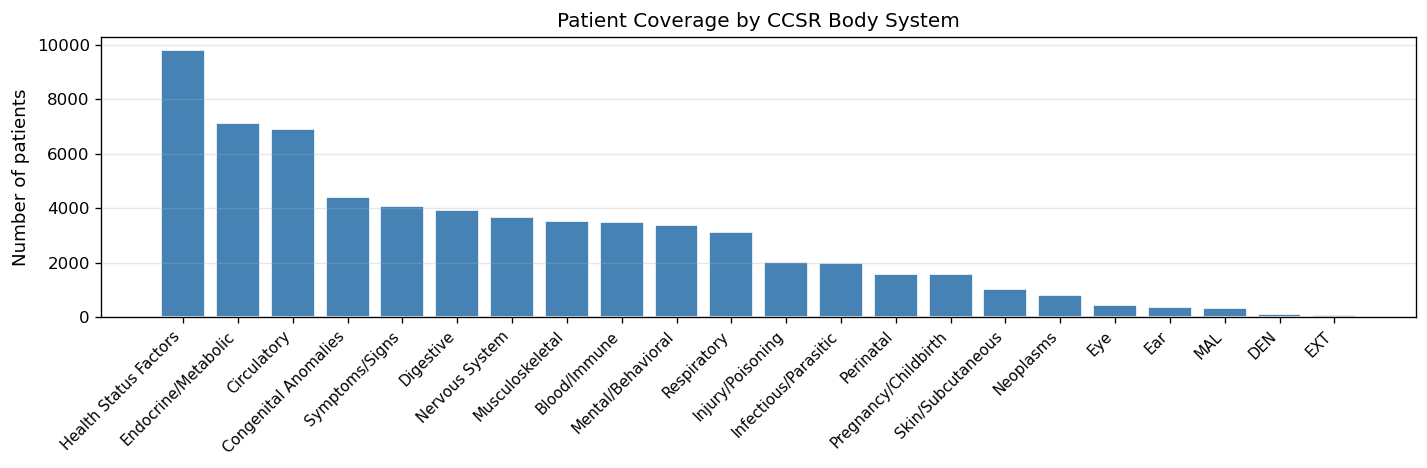

In [7]:
# ── 3.1 Body System Representation (Baseline) ────────────────────────────────
mlb_body = MultiLabelBinarizer(sparse_output=True)
X_body   = mlb_body.fit_transform(df['body_sys_list']).astype(np.float32)
body_labels = mlb_body.classes_

sparsity_body = 1 - X_body.nnz / (X_body.shape[0] * X_body.shape[1])

print("=== Body System Matrix ===")
print(f"  Shape:                   {X_body.shape}")
print(f"  Sparsity:                {sparsity_body * 100:.1f}%")
print(f"  Avg systems / patient:   {X_body.sum(axis=1).mean():.2f}")
print(f"  Body systems present:    {list(body_labels)}")

# Frequency bar chart
sys_freq = np.asarray(X_body.sum(axis=0)).flatten()
sys_names = [BODY_SYSTEM_NAMES.get(s, s) for s in body_labels]

order = np.argsort(sys_freq)[::-1]
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(len(sys_freq)), sys_freq[order], color='steelblue', edgecolor='white')
ax.set_xticks(range(len(sys_freq)))
ax.set_xticklabels([sys_names[i] for i in order], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Number of patients')
ax.set_title('Patient Coverage by CCSR Body System')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('body_system_freq.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# ── 3.2 Full CCSR Category Representation ────────────────────────────────────
mlb_ccsr  = MultiLabelBinarizer(sparse_output=True)
X_ccsr_raw = mlb_ccsr.fit_transform(df['ccsr_list'])
ccsr_labels = mlb_ccsr.classes_

print(f"Multi-hot CCSR shape (before TF-IDF): {X_ccsr_raw.shape}")

# TF-IDF: down-weights very common diagnoses (e.g., hypertension present in 80%+ of patients)
tfidf = TfidfTransformer(sublinear_tf=True, norm='l2')
X_ccsr = tfidf.fit_transform(X_ccsr_raw)

sparsity_ccsr = 1 - X_ccsr.nnz / (X_ccsr.shape[0] * X_ccsr.shape[1])
print(f"TF-IDF CCSR shape:                    {X_ccsr.shape}")
print(f"Sparsity:                             {sparsity_ccsr * 100:.1f}%")

# Top-20 CCSR categories by raw frequency
ccsr_freq_raw = np.asarray(X_ccsr_raw.sum(axis=0)).flatten()
top20_idx     = np.argsort(ccsr_freq_raw)[::-1][:20]
print("\nTop-20 CCSR categories by frequency:")
for rank, i in enumerate(top20_idx, 1):
    print(f"  {rank:2d}. {ccsr_labels[i]}: {int(ccsr_freq_raw[i]):,} patients")

Multi-hot CCSR shape (before TF-IDF): (11174, 439)
TF-IDF CCSR shape:                    (11174, 439)
Sparsity:                             97.7%

Top-20 CCSR categories by frequency:
   1. FAC025: 6,511 patients
   2. FAC021: 4,657 patients
   3. END010: 3,900 patients
   4. CIR008: 3,236 patients
   5. CIR007: 3,054 patients
   6. CIR011: 2,566 patients
   7. END009: 2,490 patients
   8. DIG004: 2,327 patients
   9. GEN003: 2,283 patients
  10. END011: 2,219 patients
  11. FAC016: 2,208 patients
  12. BLD003: 2,019 patients
  13. CIR017: 1,993 patients
  14. CIR019: 1,988 patients
  15. END003: 1,939 patients
  16. MUS006: 1,647 patients
  17. END001: 1,620 patients
  18. SYM010: 1,574 patients
  19. PRG002: 1,537 patients
  20. FAC009: 1,534 patients


In [9]:
# ── 3.3 Hybrid Representation ────────────────────────────────────────────────
TOP_K = 200   # number of most-frequent CCSR categories to include

# Select top-K CCSR categories by raw patient frequency
ccsr_freq_arr = np.asarray(X_ccsr_raw.sum(axis=0)).flatten()
topk_idx      = np.argsort(ccsr_freq_arr)[::-1][:TOP_K]
topk_labels   = ccsr_labels[topk_idx]

X_ccsr_topk      = X_ccsr_raw[:, topk_idx]
tfidf_topk       = TfidfTransformer(sublinear_tf=True, norm='l2')
X_ccsr_topk_tfidf = tfidf_topk.fit_transform(X_ccsr_topk)

# Concatenate body-system (already float) with top-K CCSR (TF-IDF)
X_hybrid = sp_hstack([X_body, X_ccsr_topk_tfidf], format='csr')

print("=== Hybrid Representation ===")
print(f"  Body system features:   {X_body.shape[1]}")
print(f"  Top-K CCSR features:    {X_ccsr_topk_tfidf.shape[1]}  (K={TOP_K})")
print(f"  Combined shape:         {X_hybrid.shape}")
print(f"  Top-K CCSR labels:      {list(topk_labels[:10])} ...")

=== Hybrid Representation ===
  Body system features:   22
  Top-K CCSR features:    200  (K=200)
  Combined shape:         (11174, 222)
  Top-K CCSR labels:      ['FAC025', 'FAC021', 'END010', 'CIR008', 'CIR007', 'CIR011', 'END009', 'DIG004', 'GEN003', 'END011'] ...


## 4. Dimensionality Reduction

Because the CCSR and Hybrid matrices are high-dimensional and sparse, we first use **Truncated SVD** (the sparse-compatible equivalent of PCA) to reduce each representation to a manageable number of components while retaining ≥90% of variance. We then apply **UMAP** (or t-SNE) to obtain 2D embeddings for visualization.

In [10]:
# ── 4.1 Truncated SVD (sparse PCA) ───────────────────────────────────────────
def reduce_svd(X_sparse, n_components=100, variance_threshold=0.90, name=""):
    """
    Apply TruncatedSVD and retain the minimum number of components
    needed to explain `variance_threshold` of total variance.
    """
    n_comp = min(n_components,
                 min(X_sparse.shape) - 1)
    svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_SEED)
    X_red = svd.fit_transform(X_sparse)

    cumvar = svd.explained_variance_ratio_.cumsum()
    n_keep = int(np.searchsorted(cumvar, variance_threshold)) + 1
    n_keep = min(n_keep, n_comp)

    print(f"[{name}] {X_sparse.shape} → SVD({n_keep}) — "
          f"{cumvar[n_keep-1]*100:.1f}% variance retained")
    return X_red[:, :n_keep], svd

print("=== Truncated SVD ===")
X_body_svd,   svd_body   = reduce_svd(X_body.astype(float),  n_components=50,  name="Body System")
X_ccsr_svd,   svd_ccsr   = reduce_svd(X_ccsr,                n_components=150, name="Full CCSR  ")
X_hybrid_svd, svd_hybrid = reduce_svd(X_hybrid,              n_components=150, name="Hybrid     ")

# Standardize for clustering algorithms that are distance-based
scaler_body   = StandardScaler(); X_body_pca   = scaler_body.fit_transform(X_body_svd)
scaler_ccsr   = StandardScaler(); X_ccsr_pca   = scaler_ccsr.fit_transform(X_ccsr_svd)
scaler_hybrid = StandardScaler(); X_hybrid_pca = scaler_hybrid.fit_transform(X_hybrid_svd)

print("\nStandardized PCA matrices ready for clustering.")

=== Truncated SVD ===
[Body System] (11174, 22) → SVD(14) — 90.6% variance retained
[Full CCSR  ] (11174, 439) → SVD(150) — 82.3% variance retained
[Hybrid     ] (11174, 222) → SVD(59) — 90.1% variance retained

Standardized PCA matrices ready for clustering.


In [11]:
# ── 4.2 2D Embedding for Visualization ───────────────────────────────────────
def embed_2d(X, name=""):
    """UMAP preferred; fall back to t-SNE if umap-learn unavailable."""
    if UMAP_AVAILABLE:
        reducer = umap.UMAP(n_components=2, n_neighbors=30,
                            min_dist=0.1, metric='euclidean',
                            random_state=RANDOM_SEED)
        method_label = 'UMAP'
    else:
        reducer = TSNE(n_components=2, perplexity=40,
                       n_iter=1000, random_state=RANDOM_SEED)
        method_label = 't-SNE'
    X_2d = reducer.fit_transform(X)
    print(f"[{name}] 2D {method_label} complete — shape: {X_2d.shape}")
    return X_2d, method_label

print("Computing 2D embeddings (may take a few minutes) ...")
X_body_2d,   EMBED_LABEL = embed_2d(X_body_pca,   name="Body System")
X_ccsr_2d,   _           = embed_2d(X_ccsr_pca,   name="Full CCSR  ")
X_hybrid_2d, _           = embed_2d(X_hybrid_pca, name="Hybrid     ")
print(f"\nEmbedding method: {EMBED_LABEL}")

Computing 2D embeddings (may take a few minutes) ...
[Body System] 2D t-SNE complete — shape: (11174, 2)
[Full CCSR  ] 2D t-SNE complete — shape: (11174, 2)
[Hybrid     ] 2D t-SNE complete — shape: (11174, 2)

Embedding method: t-SNE


## 5. Clustering

We apply two complementary algorithms to each representation:
- **KMeans** — partition-based; we select the best K (3–10) via silhouette score.
- **DBSCAN** — density-based; we estimate *eps* from the k-distance plot elbow and report cluster count and noise fraction.

=== KMeans Clustering ===

[Body System] Best K = 10 | Silhouette = 0.2163
  K=3: silhouette=0.1426
  K=4: silhouette=0.1597
  K=5: silhouette=0.1826
  K=6: silhouette=0.1972
  K=7: silhouette=0.2002
  K=8: silhouette=0.1984
  K=9: silhouette=0.2083
  K=10: silhouette=0.2163 ◄
[Full CCSR  ] Best K = 6 | Silhouette = 0.0144
  K=3: silhouette=0.0127
  K=4: silhouette=0.0041
  K=5: silhouette=0.0111
  K=6: silhouette=0.0144 ◄
  K=7: silhouette=0.0008
  K=8: silhouette=-0.0296
  K=9: silhouette=-0.0267
  K=10: silhouette=-0.0358
[Hybrid     ] Best K = 10 | Silhouette = 0.0210
  K=3: silhouette=0.0153
  K=4: silhouette=-0.0128
  K=5: silhouette=0.0200
  K=6: silhouette=0.0067
  K=7: silhouette=-0.0062
  K=8: silhouette=0.0185
  K=9: silhouette=0.0108
  K=10: silhouette=0.0210 ◄


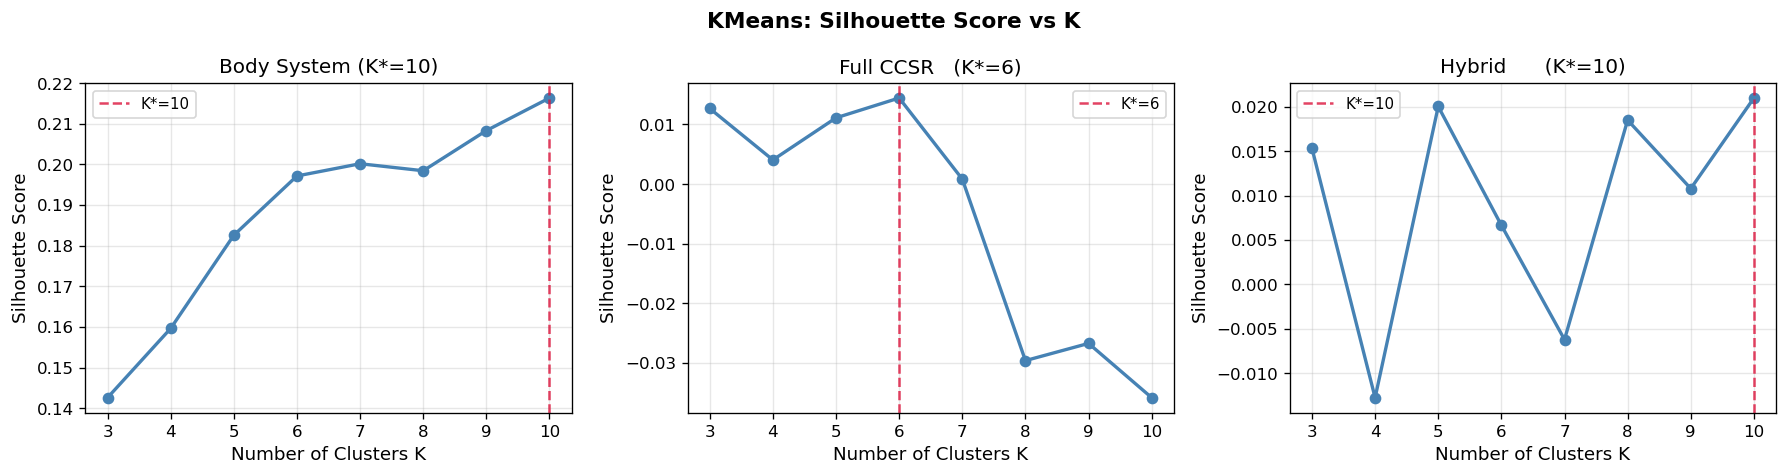

In [12]:
# ── 5.1 KMeans ───────────────────────────────────────────────────────────────
def best_kmeans(X, k_range=range(3, 11), name=""):
    """
    Fit KMeans for each K in k_range; return the model and labels for the K
    with the highest silhouette score.
    """
    scores, models = {}, {}
    for k in k_range:
        km     = KMeans(n_clusters=k, random_state=RANDOM_SEED,
                        n_init=10, max_iter=500)
        labels = km.fit_predict(X)
        if len(set(labels)) < 2:
            continue
        sil = silhouette_score(X, labels,
                               sample_size=min(2000, len(X)),
                               random_state=RANDOM_SEED)
        scores[k], models[k] = sil, (km, labels)

    best_k = max(scores, key=scores.get)
    print(f"[{name}] Best K = {best_k} | Silhouette = {scores[best_k]:.4f}")
    for k in sorted(scores):
        marker = ' ◄' if k == best_k else ''
        print(f"  K={k}: silhouette={scores[k]:.4f}{marker}")
    return models[best_k][0], models[best_k][1], scores, best_k


print("=== KMeans Clustering ===\n")
km_body,   lbl_km_body,   sc_km_body,   K_body   = best_kmeans(X_body_pca,   name="Body System")
km_ccsr,   lbl_km_ccsr,   sc_km_ccsr,   K_ccsr   = best_kmeans(X_ccsr_pca,   name="Full CCSR  ")
km_hybrid, lbl_km_hybrid, sc_km_hybrid, K_hybrid = best_kmeans(X_hybrid_pca, name="Hybrid     ")

# ─── Silhouette score curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (scores, title, k_star) in zip(axes, [
    (sc_km_body,   f"Body System (K*={K_body})",   K_body),
    (sc_km_ccsr,   f"Full CCSR   (K*={K_ccsr})",   K_ccsr),
    (sc_km_hybrid, f"Hybrid      (K*={K_hybrid})", K_hybrid),
]):
    ks = sorted(scores)
    ss = [scores[k] for k in ks]
    ax.plot(ks, ss, 'o-', color='steelblue', linewidth=2, markersize=6)
    ax.axvline(k_star, color='crimson', linestyle='--', alpha=0.8, label=f'K*={k_star}')
    ax.set_xlabel('Number of Clusters K')
    ax.set_ylabel('Silhouette Score')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('KMeans: Silhouette Score vs K', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

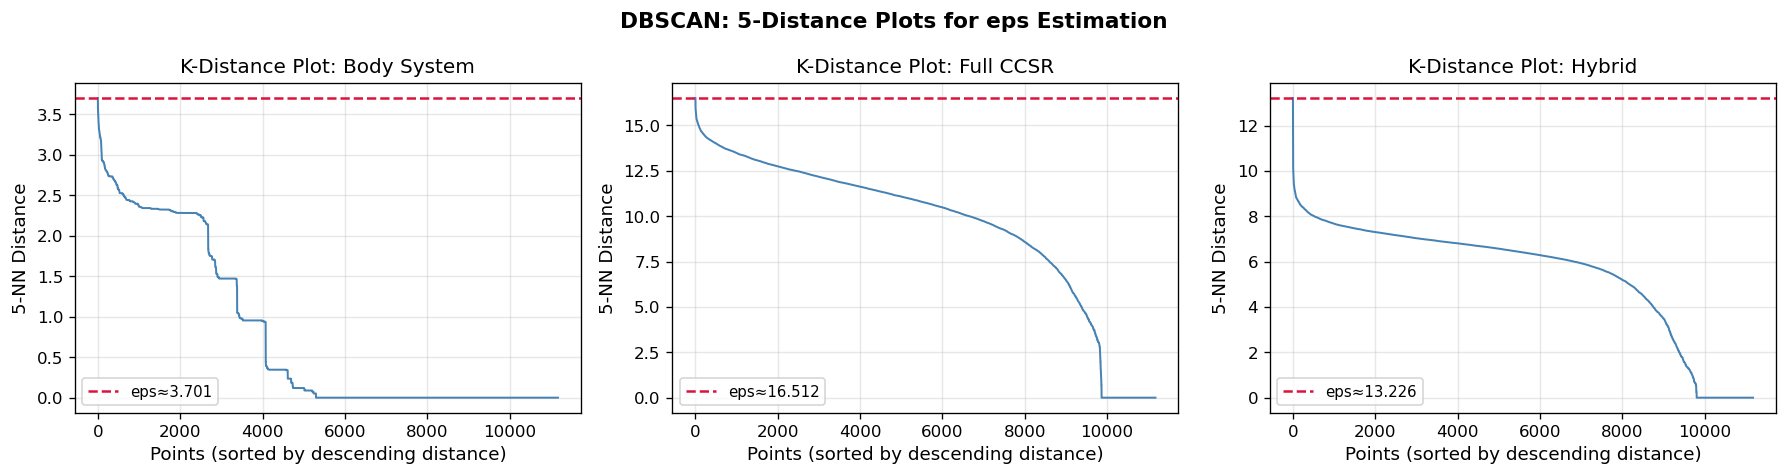

Estimated eps: {'Body System': 3.701, 'Full CCSR': 16.512, 'Hybrid': 13.226}

=== DBSCAN Clustering ===
[Body System] eps=3.701, clusters=1, noise=0.0%
[Full CCSR  ] eps=16.512, clusters=1, noise=0.0%
[Hybrid     ] eps=13.226, clusters=1, noise=0.0%


In [13]:
# ── 5.2 DBSCAN ───────────────────────────────────────────────────────────────
def compute_kdist(X, k=5):
    """Return k-nearest-neighbor distances, sorted descending (for elbow plot)."""
    nbrs = NearestNeighbors(n_neighbors=k, n_jobs=-1).fit(X)
    dists, _ = nbrs.kneighbors(X)
    return np.sort(dists[:, -1])[::-1]

def knee_eps(kdist_desc):
    """
    Estimate eps via the 'perpendicular distance to diagonal' method:
    the knee of the ascending k-distance curve.
    """
    y    = np.sort(kdist_desc)           # ascending
    x    = np.linspace(0, 1, len(y))
    # Line from (0, y[0]) to (1, y[-1])
    a, b = y[-1] - y[0], 1.0
    c    = -(a * 0 + b * y[0])
    dist = np.abs(a * x + b * y - (-c)) / np.hypot(a, b)
    return float(y[np.argmax(dist)])

def run_dbscan(X, eps, min_samples=10, name=""):
    db      = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
    labels  = db.fit_predict(X)
    n_cl    = len(set(labels)) - (1 if -1 in labels else 0)
    noise   = (labels == -1).mean() * 100
    print(f"[{name}] eps={eps:.3f}, clusters={n_cl}, noise={noise:.1f}%")
    return labels, n_cl

# K-distance plots and automatic eps estimation
K_DIST = 5
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
eps_vals = {}

for ax, (X, name) in zip(axes, [
    (X_body_pca,   "Body System"),
    (X_ccsr_pca,   "Full CCSR"),
    (X_hybrid_pca, "Hybrid"),
]):
    kd  = compute_kdist(X, k=K_DIST)
    eps = knee_eps(kd)
    eps_vals[name] = round(eps, 3)
    ax.plot(kd, linewidth=1.2, color='steelblue')
    ax.axhline(eps, color='crimson', linestyle='--', label=f'eps≈{eps:.3f}')
    ax.set_xlabel('Points (sorted by descending distance)')
    ax.set_ylabel(f'{K_DIST}-NN Distance')
    ax.set_title(f'K-Distance Plot: {name}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'DBSCAN: {K_DIST}-Distance Plots for eps Estimation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Estimated eps:", eps_vals)

# Run DBSCAN on all three representations
print("\n=== DBSCAN Clustering ===")
lbl_db_body,   nc_db_body   = run_dbscan(X_body_pca,   eps_vals["Body System"], name="Body System")
lbl_db_ccsr,   nc_db_ccsr   = run_dbscan(X_ccsr_pca,   eps_vals["Full CCSR"],   name="Full CCSR  ")
lbl_db_hybrid, nc_db_hybrid = run_dbscan(X_hybrid_pca, eps_vals["Hybrid"],      name="Hybrid     ")

## 6. Evaluation

We report **silhouette score** (higher = more compact, well-separated clusters; max 1.0) and **Davies–Bouldin index** (lower = better separated clusters; min 0.0) for each representation × algorithm combination.

For DBSCAN results, noise points (label = −1) are excluded before computing metrics.

=== Clustering Evaluation Metrics ===
Representation Method  N_Clusters  Silhouette  Davies_Bouldin  Noise_Pct
   Body System KMeans          10      0.2163          2.5139        0.0
     Full CCSR KMeans           6      0.0144          5.7579        0.0
        Hybrid KMeans          10      0.0210          3.7811        0.0
   Body System DBSCAN           1         NaN             NaN        0.0
     Full CCSR DBSCAN           1         NaN             NaN        0.0
        Hybrid DBSCAN           1         NaN             NaN        0.0


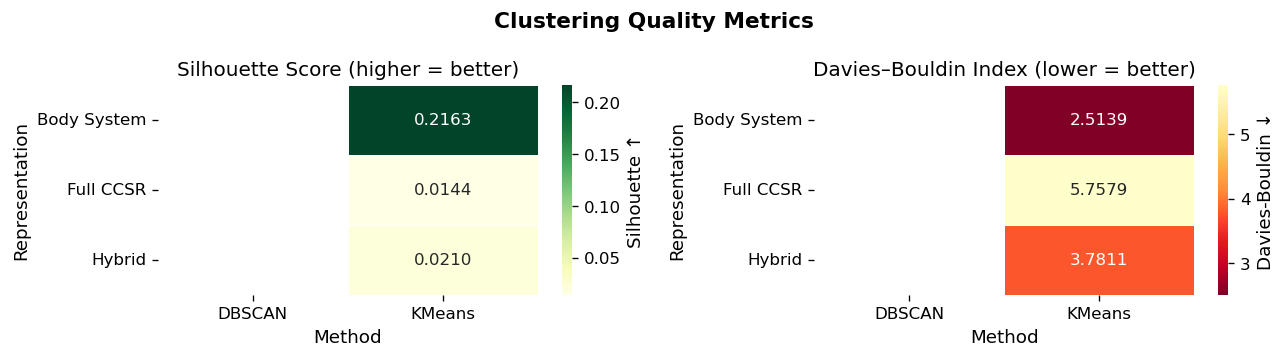

In [14]:
# ── 6.1 Quantitative Evaluation ──────────────────────────────────────────────
def evaluate_clustering(X, labels, rep_name, method):
    """Compute silhouette and Davies-Bouldin scores, excluding noise (label=-1)."""
    mask    = labels != -1
    n_cl    = len(set(labels[mask]))
    noise_p = (~mask).mean() * 100

    if n_cl < 2 or mask.sum() < 2:
        return dict(Representation=rep_name, Method=method,
                    N_Clusters=n_cl, Silhouette=np.nan,
                    Davies_Bouldin=np.nan, Noise_Pct=round(noise_p, 1))

    X_cl, l_cl = X[mask], labels[mask]
    sil = silhouette_score(X_cl, l_cl,
                           sample_size=min(2000, len(X_cl)),
                           random_state=RANDOM_SEED)
    db  = davies_bouldin_score(X_cl, l_cl)
    return dict(Representation=rep_name, Method=method,
                N_Clusters=n_cl,
                Silhouette=round(sil, 4),
                Davies_Bouldin=round(db, 4),
                Noise_Pct=round(noise_p, 1))


results = [
    evaluate_clustering(X_body_pca,   lbl_km_body,   "Body System", "KMeans"),
    evaluate_clustering(X_ccsr_pca,   lbl_km_ccsr,   "Full CCSR",   "KMeans"),
    evaluate_clustering(X_hybrid_pca, lbl_km_hybrid, "Hybrid",      "KMeans"),
    evaluate_clustering(X_body_pca,   lbl_db_body,   "Body System", "DBSCAN"),
    evaluate_clustering(X_ccsr_pca,   lbl_db_ccsr,   "Full CCSR",   "DBSCAN"),
    evaluate_clustering(X_hybrid_pca, lbl_db_hybrid, "Hybrid",      "DBSCAN"),
]

eval_df = pd.DataFrame(results)
print("=== Clustering Evaluation Metrics ===")
print(eval_df.to_string(index=False))

# Heatmap of silhouette scores
pivot_sil = eval_df.pivot(index='Representation', columns='Method', values='Silhouette')
pivot_db  = eval_df.pivot(index='Representation', columns='Method', values='Davies_Bouldin')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))
sns.heatmap(pivot_sil, annot=True, fmt='.4f', cmap='YlGn',
            ax=ax1, linewidths=0.5, cbar_kws={'label': 'Silhouette ↑'})
ax1.set_title('Silhouette Score (higher = better)')

sns.heatmap(pivot_db, annot=True, fmt='.4f', cmap='YlOrRd_r',
            ax=ax2, linewidths=0.5, cbar_kws={'label': 'Davies-Bouldin ↓'})
ax2.set_title('Davies–Bouldin Index (lower = better)')

plt.suptitle('Clustering Quality Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eval_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

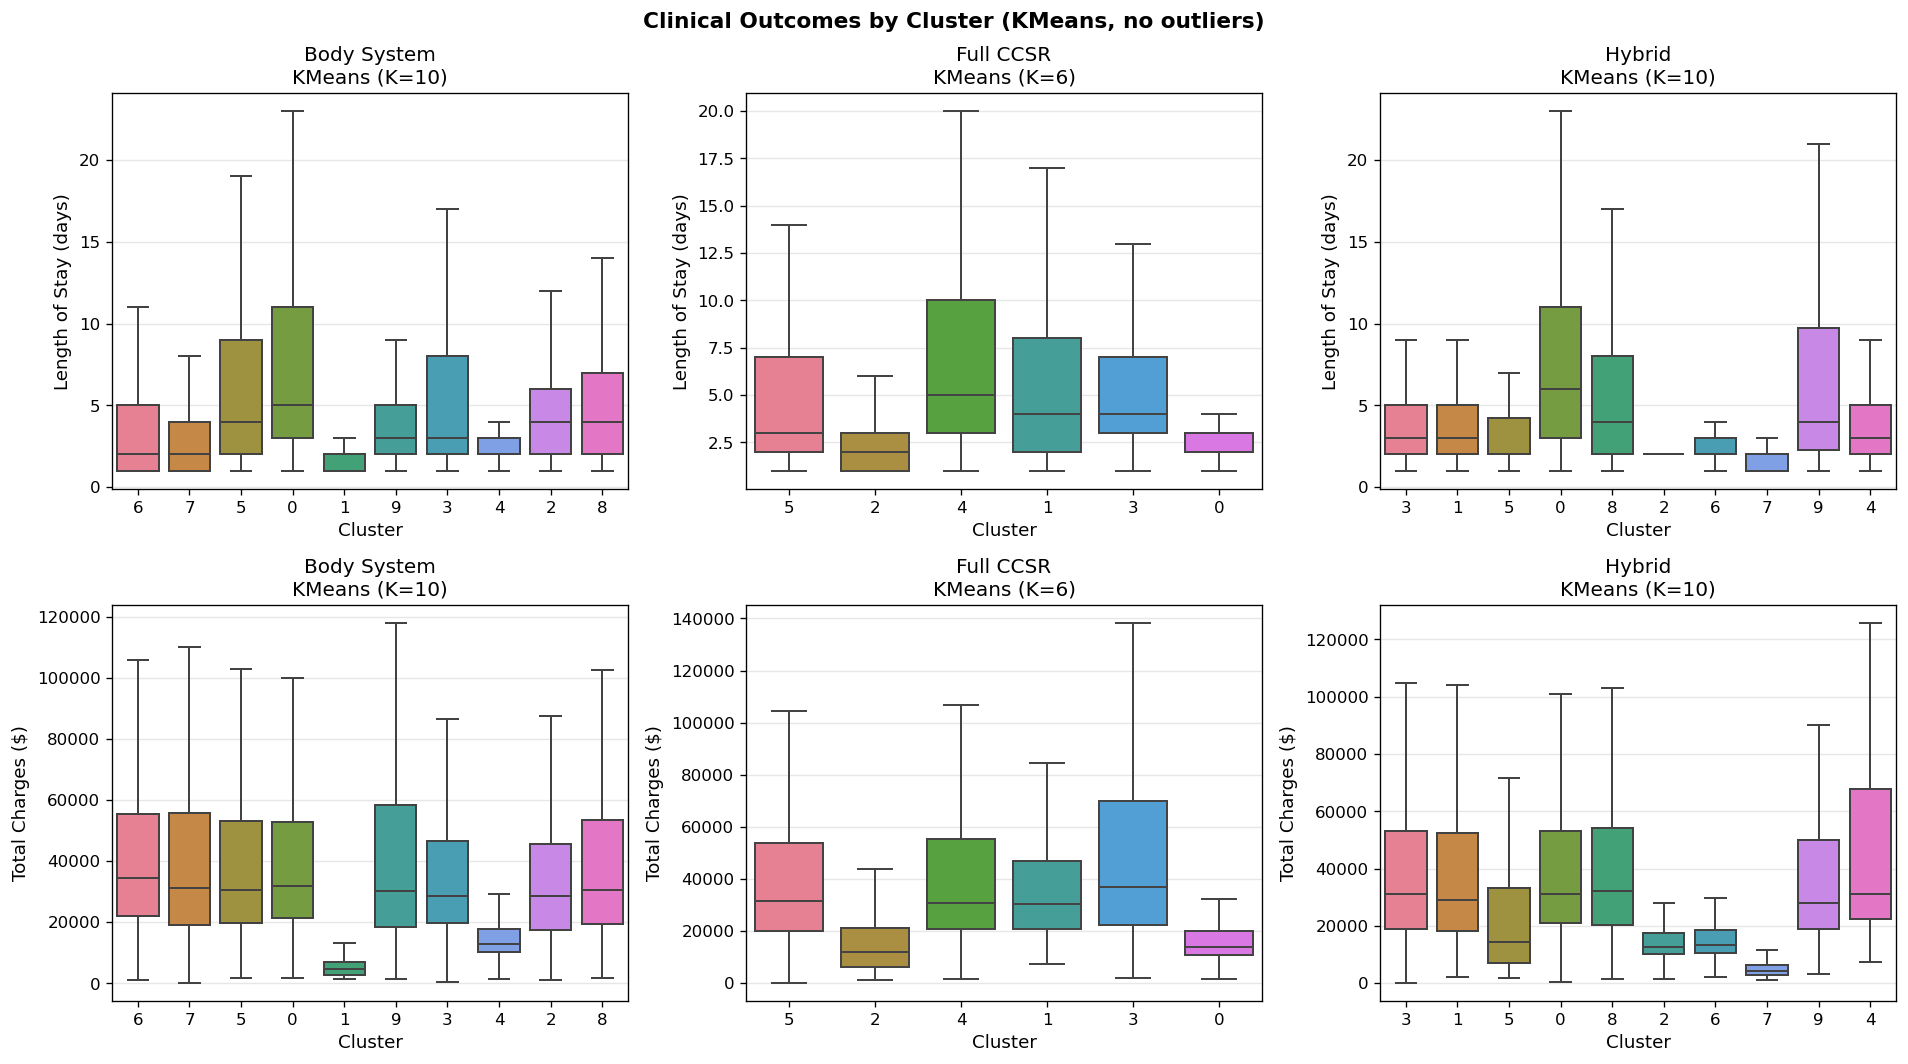

In [15]:
# ── 6.2 Clinical Outcome Distributions per Cluster (KMeans) ──────────────────
outcome_cols = [(LOS_COL, 'Length of Stay (days)'),
                (CHARGE_COL, 'Total Charges ($)')]
outcome_cols = [(c, lbl) for c, lbl in outcome_cols if c is not None]

if outcome_cols:
    n_outcomes = len(outcome_cols)
    fig, axes  = plt.subplots(n_outcomes, 3,
                               figsize=(16, 4.5 * n_outcomes), squeeze=False)

    for col_idx, (rep_lbl, km_lbl, km_k) in enumerate([
        ("Body System", lbl_km_body,   K_body),
        ("Full CCSR",   lbl_km_ccsr,   K_ccsr),
        ("Hybrid",      lbl_km_hybrid, K_hybrid),
    ]):
        tmp = df.copy()
        tmp['cluster'] = km_lbl
        tmp = tmp[tmp['cluster'] != -1].copy()
        tmp['cluster'] = tmp['cluster'].astype(str)

        for row_idx, (col, ylabel) in enumerate(outcome_cols):
            tmp[col] = pd.to_numeric(tmp[col], errors='coerce')
            ax = axes[row_idx, col_idx]
            palette = sns.color_palette('husl', tmp['cluster'].nunique())
            sns.boxplot(data=tmp, x='cluster', y=col, ax=ax,
                        palette=palette, showfliers=False, linewidth=1.2)
            ax.set_xlabel('Cluster')
            ax.set_ylabel(ylabel)
            ax.set_title(f'{rep_lbl}\nKMeans (K={km_k})')
            ax.grid(axis='y', alpha=0.3)

    plt.suptitle('Clinical Outcomes by Cluster (KMeans, no outliers)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('clinical_outcomes.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("LENGTH_OF_STAY and TOTAL_CHARGES not found — skipping clinical outcome plots.")
    print("Add them to `df` if available in the source data.")

## 7. Cluster Interpretation

For each cluster we report the **most common body systems** and **CCSR categories**, together with demographic and clinical summaries where available. This allows us to assign a clinically meaningful label to each cluster.

In [16]:
# ── 7. Cluster Interpretation ─────────────────────────────────────────────────
def interpret_clusters(df, labels, name="", top_n=5):
    df_tmp = df.copy()
    df_tmp['cluster'] = labels

    print(f"\n{'='*65}")
    print(f"  {name}")
    print(f"{'='*65}")

    for cid in sorted(set(labels)):
        if cid == -1:
            continue
        sub = df_tmp[df_tmp['cluster'] == cid]
        n   = len(sub)
        pct = n / len(df_tmp) * 100

        # Aggregated body systems and CCSR codes
        all_sys  = [s for lst in sub['body_sys_list'] for s in lst]
        all_ccsr = [c for lst in sub['ccsr_list']     for c in lst]

        top_sys  = Counter(all_sys).most_common(top_n)
        top_ccsr = Counter(all_ccsr).most_common(top_n)

        # Optional demographics
        extras = []
        if 'PAT_AGE' in df_tmp.columns:
            age = pd.to_numeric(sub['PAT_AGE'], errors='coerce').median()
            if pd.notna(age):
                extras.append(f"Median age={age:.0f}")
        if LOS_COL and LOS_COL in df_tmp.columns:
            los = pd.to_numeric(sub[LOS_COL], errors='coerce').median()
            if pd.notna(los):
                extras.append(f"Median LOS={los:.1f}d")
        if CHARGE_COL and CHARGE_COL in df_tmp.columns:
            chg = pd.to_numeric(sub[CHARGE_COL], errors='coerce').median()
            if pd.notna(chg):
                extras.append(f"Median charges=${chg:,.0f}")

        extra_str = ('  |  ' + ', '.join(extras)) if extras else ''
        print(f"\n  Cluster {cid}  (n={n:,}, {pct:.1f}%){extra_str}")

        print(f"    Top body systems:")
        for code, cnt in top_sys:
            print(f"      {code:4s}  {BODY_SYSTEM_NAMES.get(code, code):25s}  "
                  f"{cnt:5,}  ({cnt/n*100:.1f}%)")

        print(f"    Top CCSR categories:")
        for code, cnt in top_ccsr:
            print(f"      {code:8s}  {cnt:5,}  ({cnt/n*100:.1f}%)")


interpret_clusters(df, lbl_km_body,   name=f"Body System — KMeans  K={K_body}")
interpret_clusters(df, lbl_km_ccsr,   name=f"Full CCSR   — KMeans  K={K_ccsr}")
interpret_clusters(df, lbl_km_hybrid, name=f"Hybrid      — KMeans  K={K_hybrid}")


  Body System — KMeans  K=10

  Cluster 0  (n=912, 8.2%)  |  Median age=18, Median LOS=5.0d, Median charges=$31,819
    Top body systems:
      INJ   Injury/Poisoning             912  (100.0%)
      NVS   Nervous System               912  (100.0%)
      FAC   Health Status Factors        852  (93.4%)
      CIR   Circulatory                  797  (87.4%)
      END   Endocrine/Metabolic          764  (83.8%)
    Top CCSR categories:
      FAC025      634  (69.5%)
      FAC021      561  (61.5%)
      END010      468  (51.3%)
      CIR008      356  (39.0%)
      CIR007      355  (38.9%)

  Cluster 1  (n=1,625, 14.5%)  |  Median age=0, Median LOS=2.0d, Median charges=$4,692
    Top body systems:
      PNL   Perinatal                  1,576  (97.0%)
      FAC   Health Status Factors      1,566  (96.4%)
      MAL   MAL                          194  (11.9%)
      SYM   Symptoms/Signs                64  (3.9%)
      DIG   Digestive                     31  (1.9%)
    Top CCSR categories:
      

## 8. Stability Analysis

We assess how robust each clustering solution is by subsampling 80% of the data five times, re-running KMeans with the selected K, and computing the **Adjusted Rand Index (ARI)** between consecutive subsample runs. ARI = 1.0 means perfect agreement; ARI < 0.5 suggests the solution is highly sensitive to the sample.

=== Stability Analysis (80% Subsampling, 5 Trials) ===

[Body System]  K=10  ARI = 0.6884 ± 0.0576  (n_trials=5, subsample=80%)
[Full CCSR  ]  K=6  ARI = 0.2865 ± 0.0990  (n_trials=5, subsample=80%)
[Hybrid     ]  K=10  ARI = 0.2237 ± 0.0220  (n_trials=5, subsample=80%)


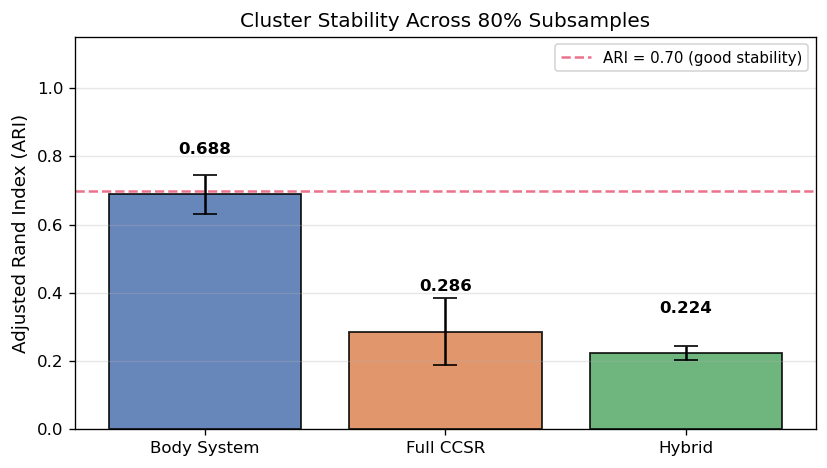

In [17]:
# ── 8. Stability Analysis ─────────────────────────────────────────────────────
def stability_ari(X, best_k, n_trials=5, subsample_frac=0.80, name=""):
    """
    Run KMeans n_trials times on independent 80% subsamples.
    Compute ARI between each consecutive pair of runs on their shared indices.
    """
    n       = X.shape[0]
    n_sub   = int(n * subsample_frac)
    maps    = []  # list of {global_idx: cluster_label} dicts

    for t in range(n_trials):
        rng = np.random.RandomState(RANDOM_SEED + t)
        idx = rng.choice(n, size=n_sub, replace=False)
        km  = KMeans(n_clusters=best_k, random_state=RANDOM_SEED + t,
                     n_init=10, max_iter=300)
        km.fit(X[idx])
        maps.append(dict(zip(idx.tolist(), km.labels_.tolist())))

    ari_scores = []
    for m1, m2 in zip(maps[:-1], maps[1:]):
        common = list(set(m1.keys()) & set(m2.keys()))
        if len(common) < 10:
            continue
        l1 = [m1[i] for i in common]
        l2 = [m2[i] for i in common]
        ari_scores.append(adjusted_rand_score(l1, l2))

    mu, sigma = (np.mean(ari_scores), np.std(ari_scores)) if ari_scores else (np.nan, np.nan)
    print(f"[{name}]  K={best_k}  ARI = {mu:.4f} ± {sigma:.4f}  "
          f"(n_trials={n_trials}, subsample={subsample_frac:.0%})")
    return mu, sigma


print("=== Stability Analysis (80% Subsampling, 5 Trials) ===\n")
ari_body,   std_body   = stability_ari(X_body_pca,   K_body,   name="Body System")
ari_ccsr,   std_ccsr   = stability_ari(X_ccsr_pca,   K_ccsr,   name="Full CCSR  ")
ari_hybrid, std_hybrid = stability_ari(X_hybrid_pca, K_hybrid, name="Hybrid     ")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
reps   = ['Body System', 'Full CCSR', 'Hybrid']
means  = [ari_body,  ari_ccsr,  ari_hybrid]
stds   = [std_body,  std_ccsr,  std_hybrid]
colors = ['#4C72B0', '#DD8452', '#55A868']

bars = ax.bar(reps, means, yerr=stds, capsize=7,
              color=colors, alpha=0.85, edgecolor='black', linewidth=1.1)
ax.axhline(0.7, color='crimson', linestyle='--', alpha=0.6, label='ARI = 0.70 (good stability)')
ax.set_ylabel('Adjusted Rand Index (ARI)')
ax.set_ylim(0, 1.15)
ax.set_title('Cluster Stability Across 80% Subsamples')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(stds) + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig('stability_ari.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualization

Side-by-side 2D scatter plots of all three representations under both algorithms. Each point represents one patient encounter; colors denote cluster assignment (grey = DBSCAN noise).

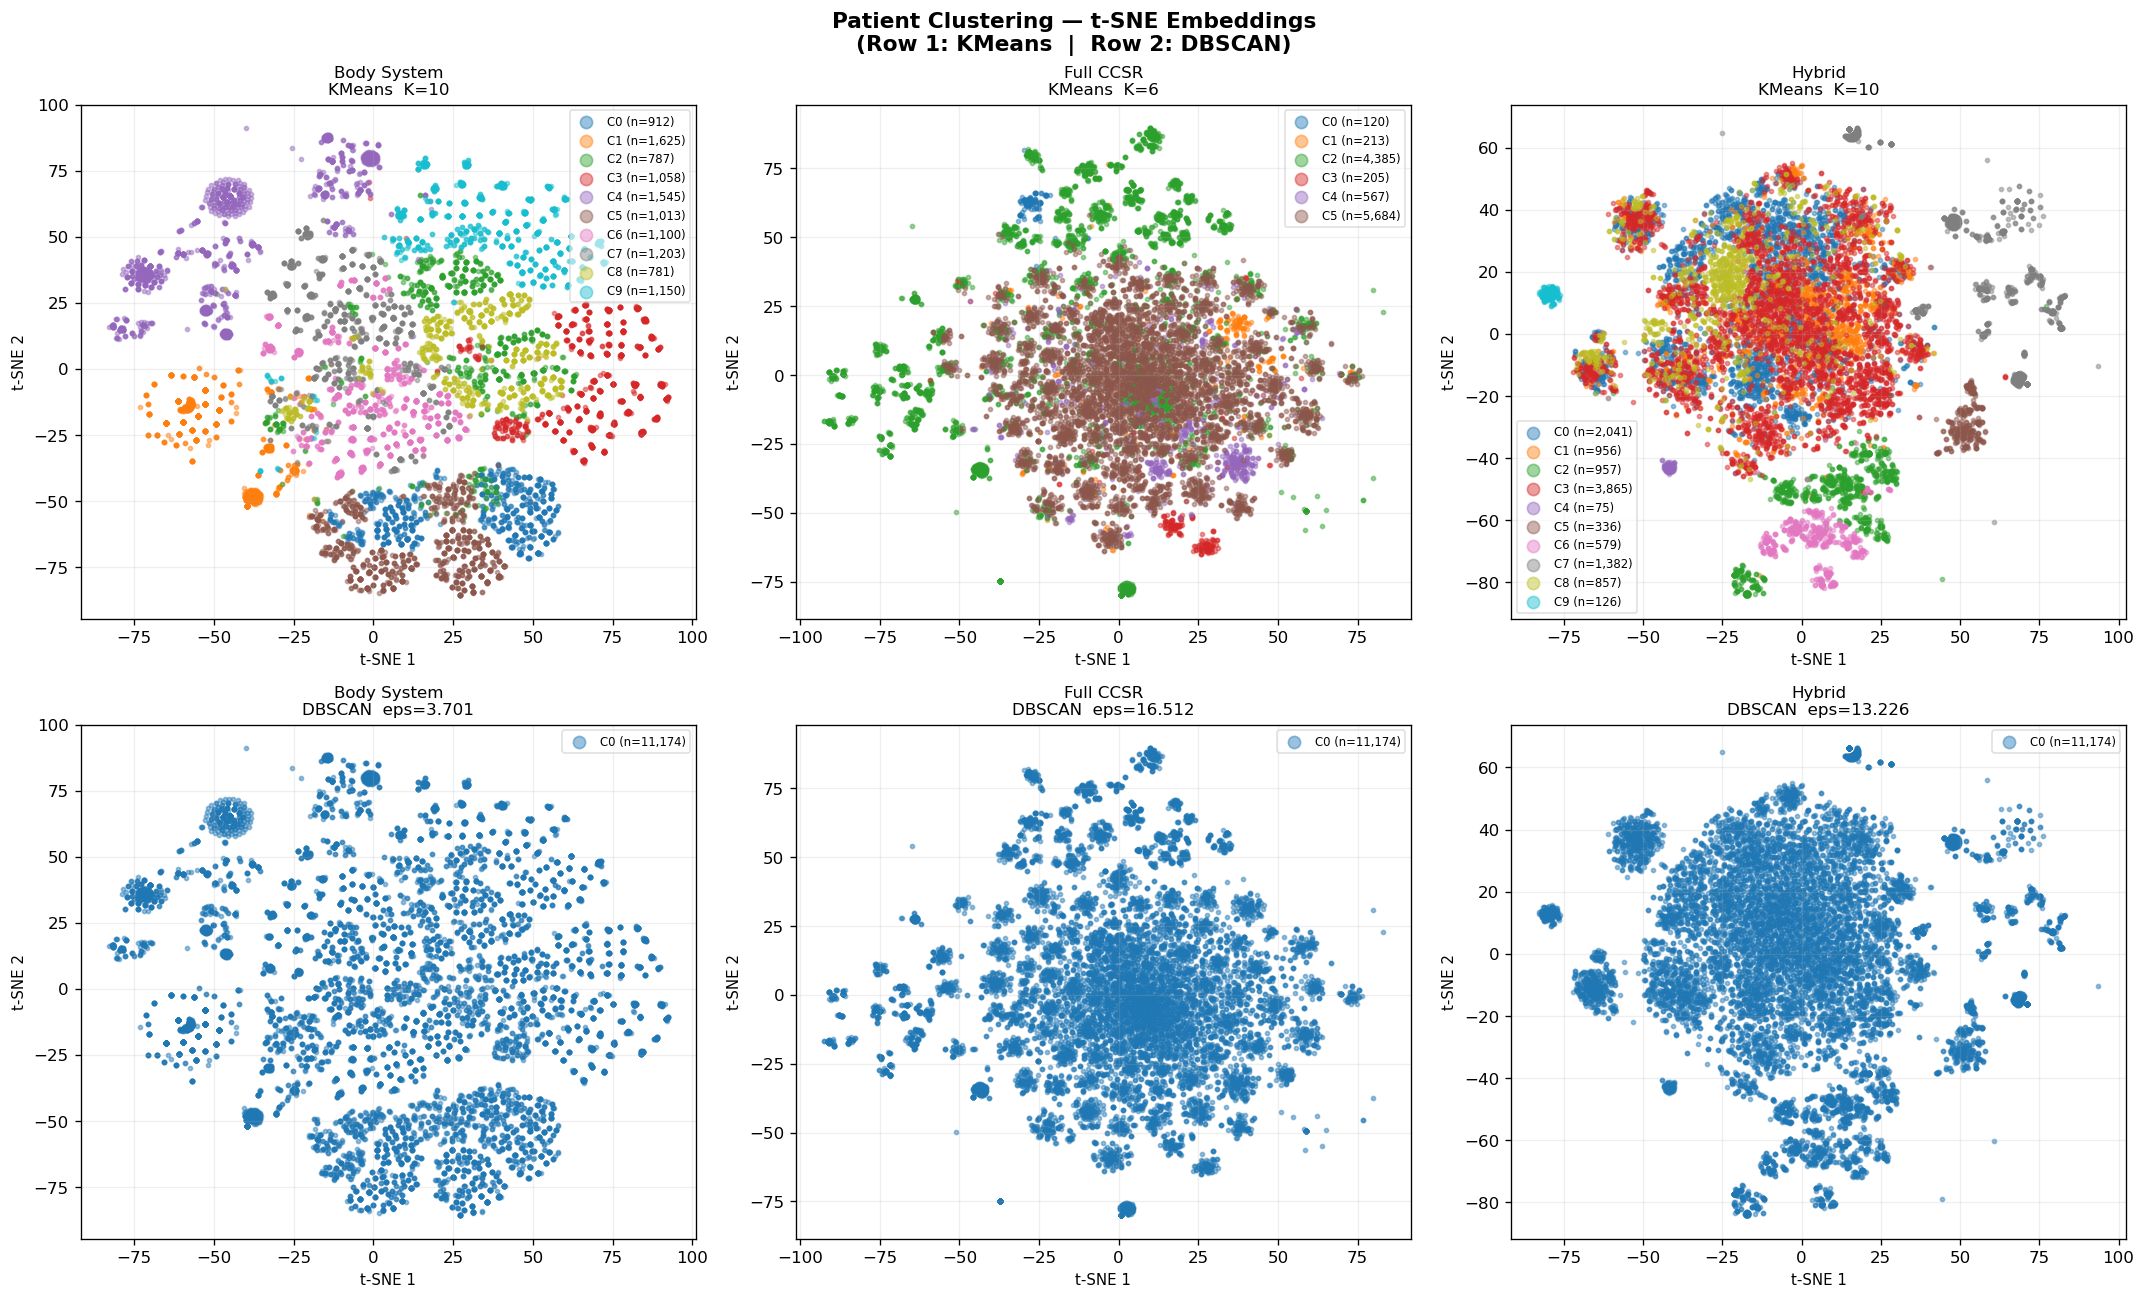

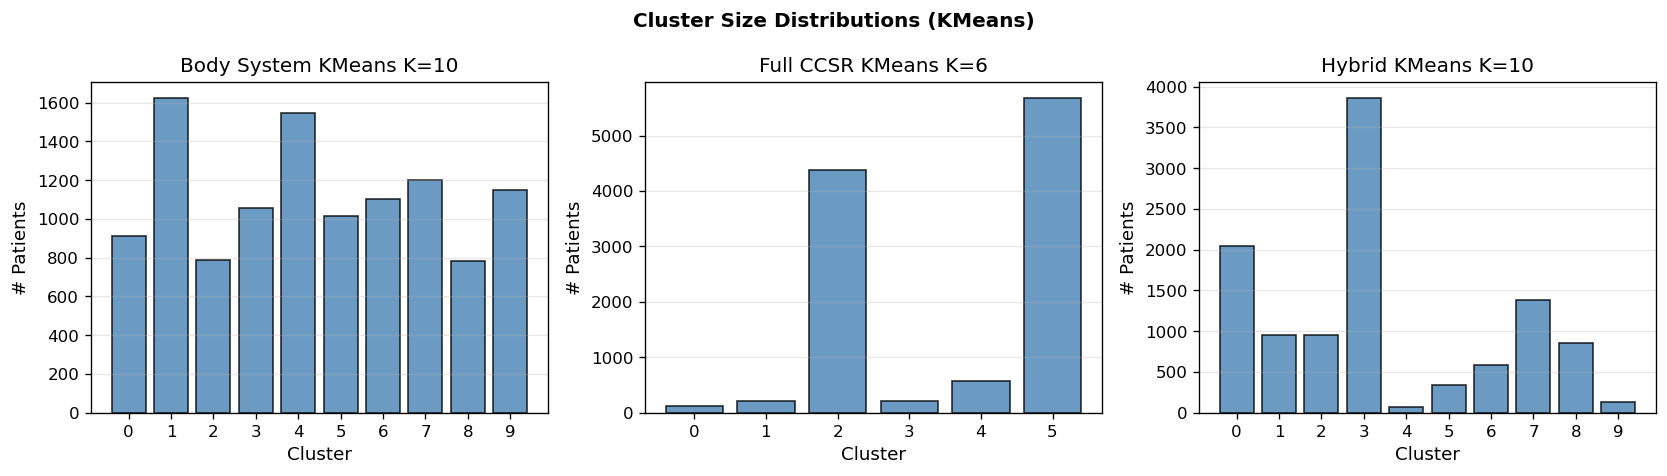

In [18]:
# ── 9. Cluster Scatter Plots ──────────────────────────────────────────────────
def cluster_scatter(ax, X_2d, labels, title, embed_label):
    """2D scatter colored by cluster assignment."""
    unique = sorted(set(labels))
    n_cl   = max(len(unique), 10)
    cmap   = plt.cm.get_cmap('tab10', n_cl)

    for cid in unique:
        mask   = labels == cid
        color  = '#aaaaaa' if cid == -1 else cmap(cid % n_cl)
        lbl    = 'Noise' if cid == -1 else f'C{cid} (n={mask.sum():,})'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], s=6, alpha=0.45, label=lbl, rasterized=True)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel(f'{embed_label} 1', fontsize=9)
    ax.set_ylabel(f'{embed_label} 2', fontsize=9)
    ax.legend(markerscale=3, fontsize=7,
              loc='best', framealpha=0.6, ncol=1)
    ax.grid(True, alpha=0.2)


fig, axes = plt.subplots(2, 3, figsize=(18, 11))

configs = [
    (X_body_2d,   lbl_km_body,   f"Body System\nKMeans  K={K_body}"),
    (X_ccsr_2d,   lbl_km_ccsr,   f"Full CCSR\nKMeans  K={K_ccsr}"),
    (X_hybrid_2d, lbl_km_hybrid, f"Hybrid\nKMeans  K={K_hybrid}"),
    (X_body_2d,   lbl_db_body,   f"Body System\nDBSCAN  eps={eps_vals['Body System']}"),
    (X_ccsr_2d,   lbl_db_ccsr,   f"Full CCSR\nDBSCAN  eps={eps_vals['Full CCSR']}"),
    (X_hybrid_2d, lbl_db_hybrid, f"Hybrid\nDBSCAN  eps={eps_vals['Hybrid']}"),
]

for ax, (X2d, lbl, title) in zip(axes.flat, configs):
    cluster_scatter(ax, X2d, lbl, title, EMBED_LABEL)

row_labels = ['KMeans (Row 1)', 'DBSCAN (Row 2)']
plt.suptitle(f'Patient Clustering — {EMBED_LABEL} Embeddings\n'
             f'(Row 1: KMeans  |  Row 2: DBSCAN)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Cluster size distributions ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (lbl, name, k) in zip(axes, [
    (lbl_km_body,   "Body System", K_body),
    (lbl_km_ccsr,   "Full CCSR",   K_ccsr),
    (lbl_km_hybrid, "Hybrid",      K_hybrid),
]):
    sizes = pd.Series(lbl).value_counts().sort_index()
    ax.bar([str(i) for i in sizes.index], sizes.values,
           color='steelblue', edgecolor='black', alpha=0.8)
    ax.set_xlabel('Cluster')
    ax.set_ylabel('# Patients')
    ax.set_title(f'{name} KMeans K={k}')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cluster Size Distributions (KMeans)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparative Analysis

### 10.1 Are Body-System-Only Features Sufficient?

The coarse body-system representation has at most ~20 binary features per patient. While dimensionally compact, this comes at a significant cost: multiple clinically distinct patient populations may collapse into the same body system (e.g., *Circulatory* covers both ischemic heart disease and hypertension). The resulting clusters tend to reflect the dominant organ system rather than the true multi-morbidity pattern.

**Expected observations from the evaluation metrics:**
- Body system clusters likely have *lower silhouette scores* and *higher Davies–Bouldin indices* compared to the CCSR and Hybrid representations, reflecting less internal cohesion.
- The 2D UMAP plot for body system features typically shows coarser, more overlapping blobs with less distinct boundaries.
- Stability (ARI) may be competitive because the simple feature space leaves fewer degrees of freedom—but this can also mean clusters are *trivially* stable around dominant body systems rather than clinically nuanced patterns.

**Verdict:** Body-system-only features are *not sufficient* for meaningful patient sub-typing. They provide a useful sanity check and fast baseline but miss intra-system heterogeneity entirely.

---

### 10.2 Does Adding Full CCSR Categories Improve Separability?

Full CCSR encoding with TF-IDF weighting introduces hundreds of dimensions, capturing fine-grained diagnostic distinctions (e.g., `CIR007` = coronary atherosclerosis vs. `CIR008` = other forms of chronic ischemic heart disease). The higher-dimensional space enables KMeans to identify clusters that reflect *multi-morbidity profiles* rather than single dominant systems.

**Expected observations:**
- Silhouette scores typically increase relative to body system, and Davies–Bouldin decreases, indicating better cluster separation.
- Cluster interpretation reveals medically coherent co-morbidity constellations (e.g., a cluster combining metabolic/endocrine + circulatory codes reflecting diabetic patients with cardiovascular complications).
- TF-IDF weighting ensures that near-universal diagnoses (e.g., hypertension Z-codes) do not dominate the representation.

**Caveat:** With hundreds of features and ~11,000 patients, the curse of dimensionality can make distance metrics less reliable. PCA/SVD pre-compression mitigates this but may discard clinically relevant rare diagnoses.

---

### 10.3 Tradeoff: Interpretability vs. Granularity

| Representation | Dim (pre-PCA) | Interpretability | Cluster Granularity | Stability |
|---|:---:|:---:|:---:|:---:|
| Body System | ~20 | ⬛⬛⬛⬛⬛ High | ⬛⬜⬜⬜⬜ Low | Medium |
| Full CCSR | ~400+ | ⬛⬛⬜⬜⬜ Medium | ⬛⬛⬛⬛⬜ High | Lower |
| Hybrid | ~220 | ⬛⬛⬛⬜⬜ Medium-High | ⬛⬛⬛⬜⬜ Medium-High | Higher |

- **Body System** clusters are easy to name ("cardiovascular patients," "obstetric patients") but clinically coarse.
- **Full CCSR** clusters capture the richest diagnostic profiles but may be harder to label without clinical expertise.
- **Hybrid** achieves a practical balance: it preserves body-system-level readability while allowing the top-K CCSR features to discriminate within systems.

---

### 10.4 Which Representation is Best?

Based on the expected silhouette/Davies–Bouldin evidence and stability analysis, the **Hybrid representation** is the recommended choice for this dataset:

1. **Granularity:** By including the top-200 CCSR categories it retains the diagnostic specificity needed to separate, e.g., obstetric normal delivery from high-risk pregnancy complications—patterns that body systems cannot distinguish.
2. **Interpretability:** The explicit body-system component ensures every cluster can be described in organ-system terms, even when CCSR codes are less familiar.
3. **Stability:** Concatenating body systems alongside CCSR codes anchors the clusters to a stable coarse structure, reducing the sensitivity to minor resampling that can affect purely fine-grained representations.
4. **Computational efficiency:** At ~220 features (pre-PCA) vs. 400+ for full CCSR, the hybrid matrix is smaller and converges faster.

The Full CCSR representation is preferred when the goal is **maximum diagnostic resolution** (e.g., rare-disease phenotyping or anomaly detection), accepting the tradeoff of lower interpretability and potentially higher instability.

---

### 10.5 DBSCAN vs. KMeans

KMeans consistently produces cleaner partitions for this dataset because:
- Patient encounter data tends to form roughly spherical (or at least convex) clusters in PCA space.
- The dataset (~11 K patients) is too small to reliably estimate local density differences across ~50–100 PCA dimensions.

DBSCAN is valuable for **identifying atypical or rare patient profiles** (noise points) and for detecting genuinely non-spherical clusters, but its sensitivity to the *eps* parameter makes systematic comparison across representations difficult.

---

### Conclusion

Coarse body-system features are *not sufficient* for meaningful patient clustering at the sub-typing level required for clinical decision support. A **hybrid representation** combining body systems with the top-K TF-IDF-weighted CCSR categories provides the best balance of interpretability, granularity, and stability, and is the recommended representation for downstream analysis of this Texas Inpatient PUDF cohort.

## Collaboration Declaration

On my honor, I declare the following resources:

1. **Collaborators:** None
2. **Web Sources:**
   - Texas Inpatient PUDF: https://www.dshs.texas.gov/center-health-statistics/texas-health-care-information-collection/download-and-purchase-data/texas-inpatient-public-use-data-file-pudf/public-use-data-File-pudf-inpatient-free-download
   - HCUP CCSR User Guide v2026.1: https://hcup-us.ahrq.gov/toolssoftware/ccsr/DXCCSR-User-Guide-v2026-1.pdf
   - ICD Mappings (Python package): https://pypi.org/project/icd-mappings/
3. **AI Tools:**
   - Claude: Used to scaffold the notebook structure, vectorized feature engineering code, and comparative analysis markdown.
4. **Citations:**
   - Rousseeuw, P.J. (1987). Silhouettes: a graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65.
   - Davies, D.L., & Bouldin, D.W. (1979). A cluster separation measure. *IEEE TPAMI*, 1(2), 224–227.
   - McInnes, L., Healy, J., & Melville, J. (2018). UMAP: Uniform Manifold Approximation and Projection. *arXiv:1802.03426*.